In [24]:
import geopandas as gpd
import pandas as pd
import warnings
import os
import glob
import subprocess
import cartopy.io.shapereader as shpreader
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import rioxarray as rxr
import matplotlib.patches as mpatches
from cartopy.feature import NaturalEarthFeature
from matplotlib.patches import Rectangle
from pyproj import Transformer
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pyproj import CRS, Transformer
import geopandas as gpd
from shapely.geometry import Point
os.environ['PROJ_LIB'] = '/home/annierosen16/anaconda3/envs/firedpy_env312/share/proj'

### loading MODIS land-cover type

In [2]:
# converting all hdf files into tifs -> subprocess

hdf_files = sorted(glob.glob('/home/annierosen16/wildfire_ml/landcover/*.hdf'))

tif_dir = '/home/annierosen16/wildfire_ml/landcover/tifs'

os.makedirs(tif_dir, exist_ok=True)

for hdf in hdf_files:
    
    basename = os.path.basename(hdf).replace('.hdf', '.tif')
    
    output_tif = os.path.join(tif_dir, basename)
    
    if os.path.exists(output_tif):
        
        continue
    
    subdataset = f'HDF4_EOS:EOS_GRID:"{hdf}":MCD12Q1:LC_Type1'
    
    subprocess.run(['gdal_translate', subdataset, output_tif],
                   
                   capture_output=True)

print("Done!")

Done!


In [3]:
tif_dir = '/home/annierosen16/wildfire_ml/landcover/tifs'

# IGBP land cover code to name mapping

igbp_names = {
    
    1: 'Evergreen Needleleaf Forests',
    
    2: 'Evergreen Broadleaf Forests',
    
    3: 'Deciduous Needleleaf Forests',
    
    4: 'Deciduous Broadleaf Forests',
    
    5: 'Mixed Forests',
    
    6: 'Closed Shrublands',
    
    7: 'Open Shrublands',
    
    8: 'Woody Savannas',
    
    9: 'Savannas',
    
    10: 'Grasslands',
    
    11: 'Permanent Wetlands',
    
    12: 'Croplands',
    
    13: 'Urban and Built-up Lands',
    
    14: 'Cropland/Natural Vegetation Mosaics',
    
    15: 'Permanent Snow and Ice',
    
    16: 'Barren',
    
    17: 'Water Bodies',
    
    255: 'Unclassified'}

# tile lookup based on x coordinate ranges

def get_tile(x, y):
   
    """Determine which MODIS tile an x,y sinusoidal coordinate falls in"""
    
    tiles = {
        
        'h08v04': (-1.112e+07, -1.001e+07, 4.448e+06, 5.560e+06),
        
        'h08v05': (-1.112e+07, -1.001e+07, 3.336e+06, 4.448e+06),
        
        'h09v04': (-1.001e+07, -8.896e+06, 4.448e+06, 5.560e+06),
        
        'h09v05': (-1.001e+07, -8.896e+06, 3.336e+06, 4.448e+06),
        
        'h10v04': (-8.896e+06, -7.784e+06, 4.448e+06, 5.560e+06),
        
        'h10v05': (-8.896e+06, -7.784e+06, 3.336e+06, 4.448e+06),
        
        'h11v04': (-7.784e+06, -6.672e+06, 4.448e+06, 5.560e+06),
        
        'h11v05': (-7.784e+06, -6.672e+06, 3.336e+06, 4.448e+06),
        
        'h12v04': (-6.672e+06, -5.560e+06, 4.448e+06, 5.560e+06),
        
        'h12v05': (-6.672e+06, -5.560e+06, 3.336e+06, 4.448e+06)}
    
    for tile, (xmin, xmax, ymin, ymax) in tiles.items():
        
        if xmin <= x <= xmax and ymin <= y <= ymax:
            
            return tile
    
    return None

# load all tifs into a dictionary keyed by (tile, year)

print("Loading landcover tifs...")

lc_cache = {}

for tif in sorted(glob.glob(os.path.join(tif_dir, '*.tif'))):
    
    basename = os.path.basename(tif)
    
    # MCD12Q1.A2001001.h08v04.061.*.tif
    
    parts = basename.split('.')
    
    year = int(parts[1][1:5])
    
    tile = parts[2]
    
    lc_cache[(tile, year)] = rxr.open_rasterio(tif).squeeze()

print(f"Loaded {len(lc_cache)} tile-year combinations")

Loading landcover tifs...
Loaded 240 tile-year combinations


### loading daily (from firedpy version 1)

In [4]:
with warnings.catch_warnings():
    
    warnings.simplefilter('ignore')
    
    daily_v1 = gpd.read_file('/home/annierosen16/wildfire_ml/fired_conus_v1_2025/outputs/shapefiles/conus_to2022335_daily.gpkg')

print(f"Total unique fires: {daily_v1['id'].nunique()}")

# confirming max growth in hectares of all fires is 215,208 ha/day

print(f"Max mx_grw_km2 in ha: {daily_v1['mx_grw_km2'].max() * 100:.1f}")

Total unique fires: 97515
Max mx_grw_km2 in ha: 214207.9


In [5]:
# transformer

modis_sinu = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"

transformer = Transformer.from_crs(modis_sinu, "EPSG:4326", always_xy=True)

# one row per fire

all_fires = daily_v1.drop_duplicates(subset=['id']).copy()

all_fires['mx_grw_ha'] = all_fires['mx_grw_km2'] * 100

# convert to lat/lon

lons_all, lats_all = transformer.transform(all_fires['x'].values, all_fires['y'].values)

all_fires['lon'] = lons_all

all_fires['lat'] = lats_all

# load US boundary and filter to CONUS

us_boundary = gpd.read_file('/home/annierosen16/wildfire_ml/firedpy/ref/individual_countries/united_states_of_america.gpkg')

us_boundary = us_boundary.to_crs('EPSG:4326')

all_fires_gdf = gpd.GeoDataFrame(
    
    all_fires,
    
    geometry=gpd.points_from_xy(all_fires['lon'], all_fires['lat']),
    
    crs='EPSG:4326')

all_fires_conus = gpd.sjoin(all_fires_gdf, us_boundary[['geometry']], how='inner', predicate='within')

all_fires_conus = all_fires_conus[
    
    (all_fires_conus['lat'] >= 24) & (all_fires_conus['lat'] <= 50) &
    
    (all_fires_conus['lon'] >= -125) & (all_fires_conus['lon'] <= -66)].copy()

print(f"CONUS fires: {len(all_fires_conus)}")

CONUS fires: 91487


In [6]:
def get_landcover(x, y, ig_year):
    
    """Get IGBP landcover code for a fire pixel using the year before ignition"""
    
    lc_year = ig_year - 1
    
    # clamp to available range
    
    lc_year = max(2001, min(2019, lc_year))
    
    tile = get_tile(x, y)
    
    if tile is None:
        
        return 255, 'Unclassified'
    
    key = (tile, lc_year)
    
    if key not in lc_cache:
        
        return 255, 'Unclassified'
    
    da = lc_cache[key]
    
    # find nearest pixel
    
    lc_code = int(da.sel(x=x, y=y, method='nearest').values)
    
    lc_name = igbp_names.get(lc_code, 'Unclassified')
    
    return lc_code, lc_name

print("Assigning landcover to fires...")

all_fires_conus[['lc_code', 'lc_name']] = all_fires_conus.apply(
    
    lambda row: pd.Series(get_landcover(row['x'], row['y'], row['ig_year'])),
    
    axis=1)

print("Done!")

print(all_fires_conus['lc_name'].value_counts().head(10))

Assigning landcover to fires...
Done!
lc_name
Croplands                       31889
Grasslands                      26445
Woody Savannas                  13626
Savannas                         4731
Deciduous Broadleaf Forests      4621
Evergreen Needleleaf Forests     2723
Evergreen Broadleaf Forests      2055
Mixed Forests                    1853
Open Shrublands                  1178
Barren                            730
Name: count, dtype: int64


In [7]:
# step 2: join back to daily_v1 by id

daily_v1_lc = daily_v1.merge(
    
    all_fires_conus[['id', 'lc_code', 'lc_name']],
    
    on='id',
    
    how='inner')

print(f"\ndaily_v1_lc rows: {len(daily_v1_lc)}")

print(f"Matched: {daily_v1_lc['lc_name'].notna().sum()} / {len(daily_v1_lc)}")


daily_v1_lc rows: 2708256
Matched: 2708256 / 2708256


In [8]:
## filter out cropland

cropland_types = ['Croplands', 'Cropland/Natural Vegetation Mosaics']

daily_v1_lc = daily_v1_lc[~daily_v1_lc['lc_name'].isin(cropland_types)]

print(f"Unique fires: {daily_v1_lc['id'].nunique()}")

Unique fires: 59085


### confirming august complex contains about 1 million acres burned area total and burned map looks right

In [88]:
# -----------------------------
# 1. Ensure date is datetime
# -----------------------------

daily_v1_lc['date'] = pd.to_datetime(daily_v1_lc['date'])

# -----------------------------
# 2. MODIS sinusoidal -> lon/lat
# -----------------------------

modis_crs = CRS.from_proj4("+proj=sinu +R=6371007.181 +nadgrids=@null +wktext")

geo_crs = CRS.from_epsg(4326)

transformer = Transformer.from_crs(modis_crs, geo_crs, always_xy=True)

# x = projection_x_coordinate (m), y = projection_y_coordinate (m)

lon, lat = transformer.transform(daily_v1_lc['x'].values, daily_v1_lc['y'].values)

daily_v1_lc = daily_v1_lc.copy()

daily_v1_lc['lon'] = lon

daily_v1_lc['lat'] = lat

# -----------------------------
# 3. Define August Complex window
# -----------------------------

start_date = pd.Timestamp("2020-08-16")

end_date   = pd.Timestamp("2020-11-12")

lon_min, lon_max = -123.7, -121.5

lat_min, lat_max = 39.3, 41.3

# -----------------------------
# 4. Filter by date + bounding box
# -----------------------------

daily_v1_august_complex = daily_v1_lc[
    
    (daily_v1_lc['date'] >= start_date) &
    
    (daily_v1_lc['date'] <= end_date) &
    
    (daily_v1_lc['lon'] >= lon_min) &
    
    (daily_v1_lc['lon'] <= lon_max) &
    
    (daily_v1_lc['lat'] >= lat_min) &
    
    (daily_v1_lc['lat'] <= lat_max)].copy()

daily_v1_august_complex['tot_ar_acres'] = daily_v1_august_complex['tot_ar_km2'] * 247.105

total_acres = sum(set(daily_v1_august_complex['tot_ar_acres']))

print(f"Total acres: {total_acres:,.0f}")

Total acres: 1,103,405


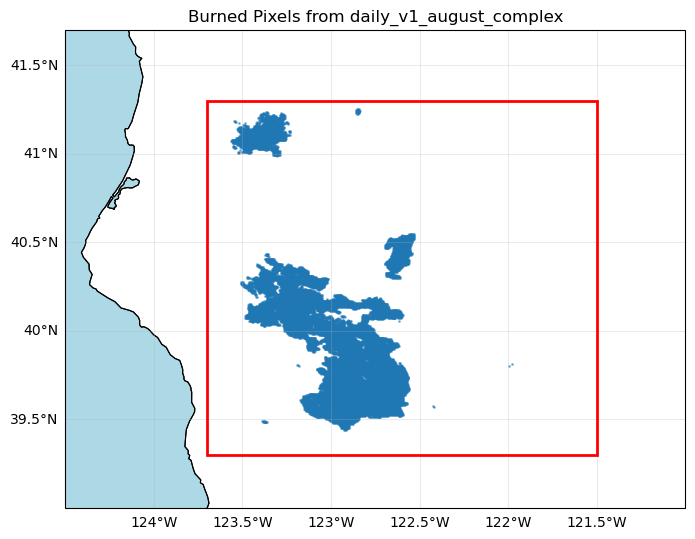

In [86]:
# ------------------------------------
# 1. Copy df and convert x/y to lon/lat
# ------------------------------------

df_plot = daily_v1_august_complex.copy()

modis_crs = CRS.from_proj4("+proj=sinu +R=6371007.181 +nadgrids=@null +wktext")

geo_crs = CRS.from_epsg(4326)

transformer = Transformer.from_crs(modis_crs, geo_crs, always_xy=True)

lon, lat = transformer.transform(df_plot['x'].values, df_plot['y'].values)

df_plot['lon'] = lon

df_plot['lat'] = lat

# Keep unique burned pixels only

df_plot = df_plot[['x', 'y', 'lon', 'lat']].drop_duplicates()

# ------------------------------------
# 2. August Complex bounding box
# ------------------------------------

lon_min, lon_max = -123.7, -121.5

lat_min, lat_max = 39.3, 41.3

# ------------------------------------
# 3. Plot
# ------------------------------------

fig = plt.figure(figsize=(8, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-124.5, -121.0, 39.0, 41.7], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

ax.add_feature(cfeature.BORDERS, linewidth=0.6)

ax.add_feature(cfeature.STATES, linewidth=0.8)

ax.add_feature(cfeature.LAND, facecolor='white')

ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)

gl.top_labels = False

gl.right_labels = False

# Burned pixels

ax.scatter(
    
    df_plot['lon'],
    
    df_plot['lat'],
    
    s=1,
    
    alpha=0.5,
    
    transform=ccrs.PlateCarree())

# Optional bounding box

box = mpatches.Rectangle(
    
    (lon_min, lat_min),
    
    lon_max - lon_min,
    
    lat_max - lat_min,
    
    linewidth=2,
    
    edgecolor='red',
    
    facecolor='none',
    
    transform=ccrs.PlateCarree(),
    
    zorder=5)

ax.add_patch(box)

ax.set_title("Burned Pixels from daily_v1_august_complex")

plt.show()

In [60]:
modis_sinu = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"

transformer_to_sinu = Transformer.from_crs("EPSG:4326", modis_sinu, always_xy=True)

transformer = Transformer.from_crs(modis_sinu, "EPSG:4326", always_xy=True)

# define fgr threshold

threshold = 1620

# get one row per fire

all_fires = daily_v1_lc.drop_duplicates(subset=['id']).copy()

all_fires['mx_grw_ha'] = all_fires['mx_grw_km2'] * 100

# filter for fires exceeding threshold

fgr = all_fires[all_fires['mx_grw_ha'] > threshold].copy()

print(f"Fires exceeding {threshold} ha/day: {len(fgr)}")

# top 100 fastest

fast = (fgr
        
        .sort_values('mx_grw_ha', ascending=False)
        
        .head(100)[['id', 'date', 'ig_date', 'mx_grw_dte','ig_year', 'pixels', 'dy_ar_km2', 'mx_grw_ha', 'tot_ar_km2', 'event_dur', 'x', 'y']])

fast_ids = set(fast['id'].values)

# convert coordinates

lons_fgr, lats_fgr = transformer.transform(fgr['x'].values, fgr['y'].values)

lons_fast, lats_fast = transformer.transform(fast['x'].values, fast['y'].values)

ha_vals = fast['mx_grw_ha'].values

# log scale colorbar from 20k to 160k

vmin, vmax = 20000, 160000

norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

cmap = cm.plasma_r

mask_normal = ha_vals <= 160000

mask_exceed = ha_vals > 160000

# size scaling for top 100

size_min, size_max = 20, 300

ha_capped = np.clip(ha_vals, vmin, vmax)

sizes = size_min + (size_max - size_min) * (np.log(ha_capped) - np.log(vmin)) / (np.log(vmax) - np.log(vmin))

Fires exceeding 1620 ha/day: 1686


/tmp/ipykernel_72524/2120761874.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


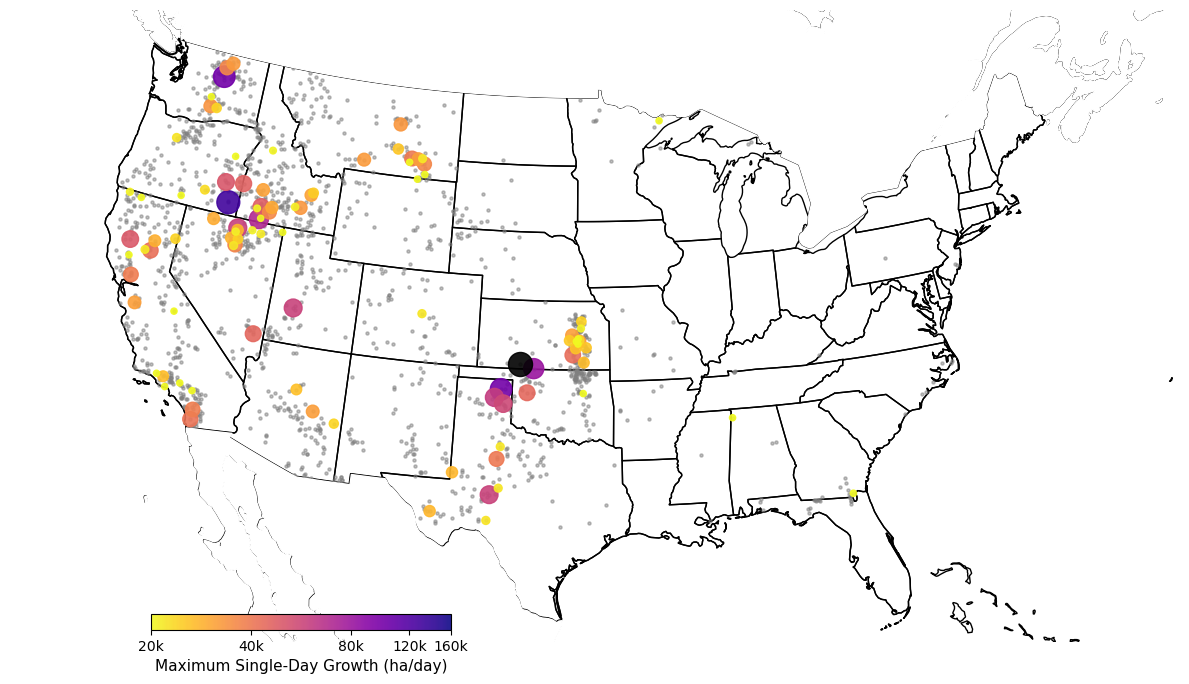

In [61]:
albers = ccrs.AlbersEqualArea(central_longitude=-96, central_latitude=37.5,
                               standard_parallels=(29.5, 45.5))
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': albers})

ax.set_extent([-124, -67, 25, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES, linewidth=1.0, edgecolor='black')

ax.add_feature(cfeature.COASTLINE, linewidth=1.0)

ax.add_feature(cfeature.BORDERS, linewidth=1.5, edgecolor='black')

ax.add_feature(cfeature.LAND, facecolor='white')

ax.add_feature(cfeature.OCEAN, facecolor='white')

# mask out mexico and canada with higher resolution

countries = shpreader.natural_earth(resolution='50m', category='cultural',
                                    name='admin_0_countries')
reader = shpreader.Reader(countries)

for country in reader.records():
    
    if country.attributes['NAME'] in ['Mexico', 'Canada']:
        
        ax.add_geometries([country.geometry], crs=ccrs.PlateCarree(),
                          facecolor='white', edgecolor='white', zorder=4)

# plot all fgr fires as small grey dots

ax.scatter(
    
    lons_fgr, lats_fgr,
    
    c='grey', s=5, alpha=0.5,
    
    transform=ccrs.PlateCarree(), zorder=3)

# plot top 100 colored

sc = ax.scatter(
    
    lons_fast[mask_normal], lats_fast[mask_normal],
    
    c=ha_vals[mask_normal],
    
    cmap=cmap, norm=norm,
    
    s=sizes[mask_normal], alpha=0.9,
    
    transform=ccrs.PlateCarree(), zorder=5)

# plot fires exceeding 160k in black

ax.scatter(
    
    lons_fast[mask_exceed], lats_fast[mask_exceed],
    
    c='black',
    
    s=sizes[mask_exceed], alpha=0.9,
    
    transform=ccrs.PlateCarree(), zorder=6)

# colorbar

cax = fig.add_axes([0.13, 0.12, 0.25, 0.02])

cbar = plt.colorbar(sc, cax=cax, orientation='horizontal')

cbar.set_label('Maximum Single-Day Growth (ha/day)', fontsize=11)

cbar.set_ticks([20000, 40000, 80000, 120000, 160000])

cbar.set_ticklabels(['20k', '40k', '80k', '120k', '160k'])

cbar.ax.minorticks_off()

cbar.ax.tick_params(labelsize=10)

ax.set_title('')

ax.axis('off')

plt.tight_layout()

plt.show()